In [1]:
import math, os

import numpy as np
import jax
from jax import Array
from jax import numpy as jnp
from jax import scipy as jsp
import matplotlib.pyplot as plt

from blueprint.qubits import TunableTransmon, KerrOscillator, HarmonicOscillator
from blueprint.devices import Device
from blueprint.pulses import flux_pulses, coupler_pulses, charge_pulses
from blueprint.pulses.flux_pulses import net_zero_transition_flux_pulse

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.90"  # for 90% of total GPU memory

# jax.config.update("jax_default_device", jax.devices("cpu")[0])
jax.config.update("jax_default_device", jax.devices("cuda")[1])
# jax.config.update("jax_enable_x64", True)  # Double
# dtype = jnp.complex128
jax.config.update("jax_enable_x64", False)  # Simple
dtype = jnp.complex64

In [2]:
# units
kHz, MHz, GHz = 1e-6, 1e-3, 1
ns, us, ms = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi

## Qubit

In [3]:
LABEL = "Q1"
CHARGING_ENERGY = 0.17874386390652913 * GHz
JOSEPHSON_ENERGY = 28.045385714769342 * GHz
ASYMMETRY = 0.617379794210013
CHARGE_CUTOFF = 100
OFFSET_CHARGE = 0.0
EXT_FLUX = 0.0
dim = 5

transmon = TunableTransmon(
    label=LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    asymmetry=ASYMMETRY,
    charge_cutoff=CHARGE_CUTOFF,
    offset_charge=OFFSET_CHARGE,
    ext_flux=EXT_FLUX,
    relax_time=None,
    deph_time=None,
)

transmon.diagonalize(dim)

## Drives

In [4]:
transmon.add_charge_drive("cosine_drive", charge_pulses.cosine_pulse)

Let's do a $\pi$ gate in 30 ns

In [5]:
transmon.frequency

Array(6.148535, dtype=float32)

In [6]:
GATE_TIME_NS = 30 * ns
AMPLITUDE_GHZ = (2 * math.pi) / GATE_TIME_NS / float(jnp.abs(transmon.charge_zpf))
CARRIER_FREQ_GHZ = float(transmon.frequency)
CARRIER_PHASE = 0.0

transmon.drives["cosine_drive"].set_params(
    amplitude_GHz=AMPLITUDE_GHZ,
    gate_time_ns=GATE_TIME_NS,
    carrier_freq_GHz=CARRIER_FREQ_GHZ,
    carrier_phase=CARRIER_PHASE,
)

AMPLITUDE_GHZ

0.022735031491075534

## Device

In [7]:
device = Device(
    [
        transmon,
    ]
)

device.index_eigenstates()

device.diagonalize()

## Dynamiqs Hamiltonian

In [8]:
import dynamiqs as dq

/home/gene2902/blueprint-env/lib/python3.11/site-packages/qutip/__init__.py:66: UserWarning: The new version of Cython, (>= 3.0.0) is not supported.
  warnings.warn(


In [9]:
def build_dynamiqs_hamiltonian(device: Device):
    dq_hamiltonian = dq.constant(device.get_hamiltonian())
    for prefactor, operator in device.get_drive_hamiltonian_terms():
        dq_hamiltonian = dq_hamiltonian + dq.modulated(prefactor, operator)
    return dq_hamiltonian

In [10]:
dq_hamiltonian = build_dynamiqs_hamiltonian(device=device)

# Single-qubit gate simulations

## Define the scope

In [11]:
# === tsave
tsave = jnp.linspace(0, GATE_TIME_NS, 31)

In [12]:
# === qubit operators and states
ket_0 = device.get_eigenstate(0)[1][:, None]
ket_1 = device.get_eigenstate(1)[1][:, None]
ket_2 = device.get_eigenstate(2)[1][:, None]
ket_3 = device.get_eigenstate(3)[1][:, None]

Id = ket_0 @ dq.dag(ket_0) + ket_1 @ dq.dag(ket_1)
X = ket_0 @ dq.dag(ket_1) + ket_1 @ dq.dag(ket_0)                 # X
Y = -1.0j * ket_0 @ dq.dag(ket_1) + 1.0j * ket_1 @ dq.dag(ket_0)  # Y
Z = ket_0 @ dq.dag(ket_0) - ket_1 @ dq.dag(ket_1)                 # Z

rho_pX = (Id + X) / 2
rho_mX = (Id - X) / 2
rho_pY = (Id + Y) / 2
rho_mY = (Id - Y) / 2
rho_pZ = (Id + Z) / 2
rho_mZ = (Id - Z) / 2

In [13]:
# === initial states
rho0 = jnp.stack(
    [
        rho_pX,
        rho_mX,
        rho_pY,
        rho_mY,
        rho_pZ,
        rho_mZ,
        ket_2 @ dq.dag(ket_2),
        ket_3 @ dq.dag(ket_3),
    ]
)
rho0.shape

(8, 5, 5)

In [14]:
# === expectation operators
exp_ops = [
    X,
    Y,
    Z,
    ket_2 @ dq.dag(ket_2),
    ket_3 @ dq.dag(ket_3)
]

In [15]:
jump_ops = [jnp.zeros((device.dim, device.dim))]

## Run the simulation

In [16]:
import time

In [17]:
# === run mesolve
t0 = time.time()
result = dq.mesolve(
    H=dq_hamiltonian,
    jump_ops=jump_ops,
    rho0=rho0,
    tsave=tsave,
    exp_ops=exp_ops,
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=100000),
    options=dq.Options(
        save_states=True,
        verbose=True,
    ),
)
tf = time.time()
print(f"Sim took {tf - t0:.2f} seconds.")
print(result)

Sim took 2.78 seconds.
==== MEResult ====
Solver   : Tsit5
States   : Array complex64 (8, 31, 5, 5) | 48.44 Kb
Expects  : Array complex64 (8, 5, 31) | 9.69 Kb
Infos    : avg. 3309.25 steps (3299.25 accepted, 10.0 rejected) | infos shape (8,)


## Get the expectation values in the qubit rotating frame

In [18]:
# === expects in rotating frame
static_hamiltonian = device.get_hamiltonian()
if jnp.allclose(jnp.diag(jnp.diag(static_hamiltonian)), static_hamiltonian):
    U0s_diags = jnp.exp(
        1.0j * tsave[:, None] * jnp.diagonal(static_hamiltonian)[None, :]
    )
    # Now embed in diags
    Nt, Ndim = U0s_diags.shape
    U0s = (
        jnp.zeros_like(U0s_diags, shape=(Nt, Ndim, Ndim))
        .at[:, jnp.arange(Ndim), jnp.arange(Ndim)]
        .set(U0s_diags)
    )
else:
    # WARNING: Seems to be very error-prone for float32 (complex64) precision
    U0s = jax.scipy.linalg.expm(1.0j * tsave[:, None, None] * static_hamiltonian[None, :, :])
# U0s: Shape ([time_len, *dims, *dims])
# result.states shape: (batch_size, time_len, *dims, *dims)
rhos_qb = U0s @ result.states @ dq.dag(U0s)
# rhos_qb = jnp.einsum('tnm,btmk->btnk', U0s, result.states)
# rhos_qb shape: (batch_size, time_len, *dims, *dims)

# exp_ops: Shape (n_expt_values, *dims, *dims)
metrajs = jnp.einsum("btnm,emn->bet", rhos_qb, jnp.array(exp_ops)).real

In [19]:
metrajs.shape

(8, 5, 31)

## Plot the results

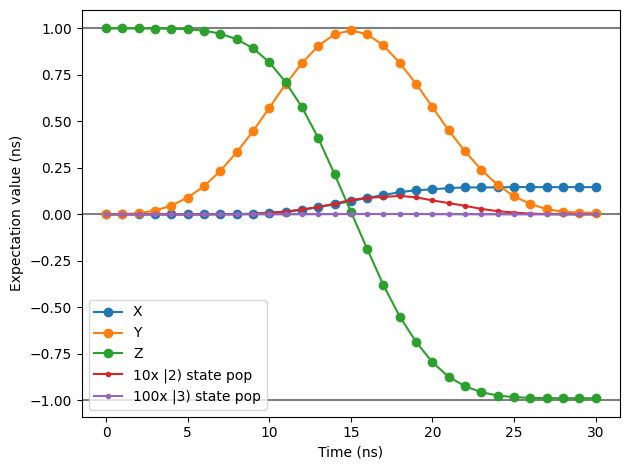

In [20]:
pidx = 4
plt.plot(tsave / ns, metrajs[pidx, 0, :], "-o", label="X")
plt.plot(tsave / ns, metrajs[pidx, 1, :], "-o", label="Y")
plt.plot(tsave / ns, metrajs[pidx, 2, :], "-o", label="Z")
plt.plot(tsave / ns, 10 * metrajs[pidx, 3, :], ".-", label="10x |2) state pop")
plt.plot(tsave / ns, 100 * metrajs[pidx, 4, :], ".-", label="100x |3) state pop")
plt.axhline(0.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(1.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(-1.0, ls="-", c="tab:gray", zorder=-1)
plt.xlabel("Time (ns)")
plt.ylabel("Expectation value (ns)")
plt.legend()
plt.tight_layout()

We are getting slightly detuned Rabi oscillations because of the ac Start shift due to the microwave drive. Can test that this gets worse with decreasing the gate length (effectively increasing the drive amplitude). Can calibrate the gate by adjusting the detuning of the carrier_freq such that omega_01 + ac_detuning is on resonance with the drive.

We are also effectively driving around -sigma_X, which is expected according to my math. Could easily fix it such that a positive I/Q quadrature driving (prefacor of cos(w_d * t)) is driving around +X/+Y as in textbook implementation.

We see about 1% leakage here for 30ns gate without DRAG, and it gets much worse with faster gates.

# TODO: Scan a gate parameter and batch mesolve()

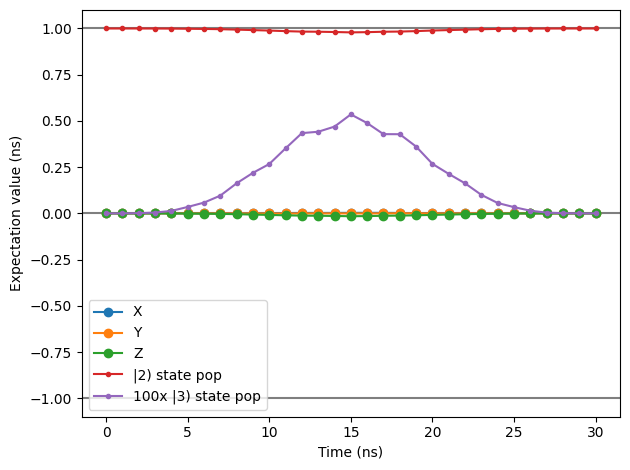

In [21]:
pidx = 6
plt.plot(tsave / ns, metrajs[pidx, 0, :], "-o", label="X")
plt.plot(tsave / ns, metrajs[pidx, 1, :], "-o", label="Y")
plt.plot(tsave / ns, metrajs[pidx, 2, :], "-o", label="Z")
plt.plot(tsave / ns, metrajs[pidx, 3, :], ".-", label="|2) state pop")
plt.plot(tsave / ns, 100 * metrajs[pidx, 4, :], ".-", label="100x |3) state pop")
plt.axhline(0.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(1.0, ls="-", c="tab:gray", zorder=-1)
plt.axhline(-1.0, ls="-", c="tab:gray", zorder=-1)
plt.xlabel("Time (ns)")
plt.ylabel("Expectation value (ns)")
plt.legend()
plt.tight_layout()

# TODO: Try the DRAG cosine pulse version and compare leakage to not DRAG

# Test the simple drive

In [22]:
times = jnp.linspace(0, GATE_TIME_NS, 201)
all_drive_amps = np.zeros((len(times),))
for t_idx, t in enumerate(times):
    hamil = dq_hamiltonian(t)
    all_drive_amps[t_idx] = float(hamil[0, 1].real)

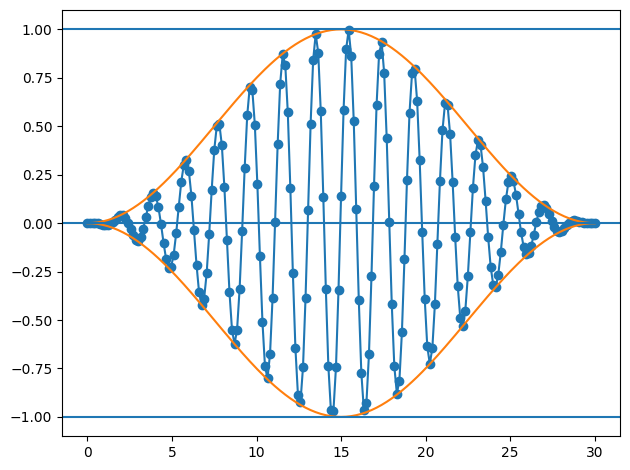

In [23]:
plt.plot(times / ns, all_drive_amps / transmon.charge_zpf / AMPLITUDE_GHZ, "-o")
plt.plot(times / ns, (1 - jnp.cos(2 * jnp.pi / GATE_TIME_NS * times)) / 2, "-", c="C1")
plt.plot(times / ns, -(1 - jnp.cos(2 * jnp.pi / GATE_TIME_NS * times)) / 2, "-", c="C1")
plt.axhline(0.)
plt.axhline(1.0)
plt.axhline(-1.0)
plt.tight_layout()